In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from pandas.api.types import is_datetime64_any_dtype

USE_COLS = ["# Timestamp","MMSI","Latitude","Longitude","SOG","COG","Heading","Navigational status","Name","Ship type"]

NOTEBOOK_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
DATA_PATH = (NOTEBOOK_DIR / ".." / "data" / "aisdk-2025-03-01.csv").resolve()
assert DATA_PATH.exists(), f"Missing data file: {DATA_PATH}"

df = pd.read_csv(
    DATA_PATH,
    usecols=lambda c: c in USE_COLS,
    dtype={
        "MMSI": "int64",
        "Latitude": "float64",
        "Longitude": "float64",
        "SOG": "float64",
        "COG": "float64",
        "Heading": "float64",
        "Navigational status": "string",
        "Name": "string",
        "Ship type": "string",
    },
)

# Timestamp is parsed separately (not inside read_csv) so the explicit format
# string stays visible and debuggable. dtype= handles all other columns at load time.
df["# Timestamp"] = pd.to_datetime(
    df["# Timestamp"], format="%d/%m/%Y %H:%M:%S", errors="coerce"
)

df = df.dropna(subset=["# Timestamp"]).copy()

# Validation
assert is_datetime64_any_dtype(df["# Timestamp"]), f"Unexpected dtype: {df['# Timestamp'].dtype}"
print(f"Time range: {df['# Timestamp'].min()} → {df['# Timestamp'].max()}")
print(f"Unique timestamps: {df['# Timestamp'].nunique()}")
print("Sample times:", df["# Timestamp"].dt.time.tail(5).tolist())

Time range: 2025-03-01 00:00:00 → 2025-03-01 23:59:58
Unique timestamps: 86399
Sample times: [datetime.time(23, 59, 58), datetime.time(23, 59, 58), datetime.time(23, 59, 58), datetime.time(23, 59, 58), datetime.time(23, 59, 58)]


### Data Types Check

In [26]:
# Check data types and sample data
print(df.dtypes)
df.head()

# Timestamp            datetime64[us]
MMSI                            int64
Latitude                      float64
Longitude                     float64
Navigational status            string
SOG                           float64
COG                           float64
Heading                       float64
Name                           string
Ship type                      string
dtype: object


,# Timestamp,MMSI,Latitude,Longitude,Navigational status,SOG,COG,Heading,Name,Ship type
0,2025-03-01,273257120,57.336578,8.189392,Under way using engine,10.9,236.8,238.0,<NA>,Undefined
1,2025-03-01,219000431,54.524650,11.239300,Under way using engine,17.4,178.3,179.0,<NA>,Undefined
2,2025-03-01,231336000,54.783100,10.353542,Under way using engine,9.2,127.2,124.0,<NA>,Undefined
3,2025-03-01,352002621,56.828723,11.867325,Under way using engine,14.4,339.2,339.0,<NA>,Undefined
4,2025-03-01,273257120,57.336578,8.189392,Under way using engine,10.9,236.8,238.0,<NA>,Undefined


### Dataset Overview

This section summarises the key properties of the AIS dataset: number of records, unique vessels, time range, and data quality indicators (invalid coordinates and missing speed values).

In [27]:
n_rows = len(df)
n_vessels = df["MMSI"].nunique()
time_min, time_max = df["# Timestamp"].min(), df["# Timestamp"].max()

# (0,0) is the standard AIS placeholder for "no GPS fix"
# We check both lat AND lon == 0 together, not separately
# (latitude 0 alone is valid — it's the equator)
invalid_coords = (df["Latitude"] == 0) & (df["Longitude"] == 0)
pos_invalid = invalid_coords.mean()
sog_missing = df["SOG"].isna().mean()

pd.DataFrame({
    "rows":[n_rows],
    "unique_vessels":[n_vessels],
    "time_min":[time_min],
    "time_max":[time_max],
    "invalid_(0,0)_frac":[pos_invalid],
    "SOG_missing_frac":[sog_missing],
})

,rows,unique_vessels,time_min,time_max,"invalid_(0,0)_frac",SOG_missing_frac
0,18977895,3685,2025-03-01,2025-03-01 23:59:58,0.0,0.077783


### Vessel Selection

One vessel is selected for detailed analysis. Invalid (0,0) coordinates — the standard AIS placeholder for "no GPS fix" — are removed first, then the vessel with the highest number of valid AIS messages is chosen.

In [28]:
# Remove only true (0,0) placeholders — both lat AND lon must be zero
df_valid = df[~((df["Latitude"] == 0) & (df["Longitude"] == 0))].copy()

moving_counts = df_valid[df_valid["SOG"].notna()]["MMSI"].value_counts()
moving_counts.head(10)


MMSI
219313000    59279
244238000    54525
257339000    50372
211190000    48546
246100000    47412
219022903    46836
219006092    46353
636018620    46340
219017895    45367
245097000    44572
Name: count, dtype: int64

In [29]:
# Select vessel with most AIS messages and extract its data
SELECTED_MMSI = int(moving_counts.index[0])  # change if you want another vessel

vessel = df_valid[df_valid["MMSI"] == SELECTED_MMSI].copy()
vessel = vessel.sort_values("# Timestamp").reset_index(drop=True)
vessel = vessel[vessel["SOG"].notna()].copy()  # keep only rows with SOG

print(f"Selected MMSI: {SELECTED_MMSI}")
print(f"Number of AIS messages: {len(vessel)}")

Selected MMSI: 219313000
Number of AIS messages: 59279


### Vessel Selection Strategy

One vessel is selected from the full dataset for depth analysis. The selection criteria prioritise data quality and activity level.

**Why not all vessels?**
- Many vessels have very few AIS messages (insufficient for meaningful analysis)
- Some vessels remain stationary throughout the period
- Some records have missing or unreliable speed data

**Selection process:**
1. **Remove (0,0) placeholders**: AIS uses (0,0) to mean "no GPS fix" — only these are dropped; latitude 0 alone is a valid equatorial position
2. **Count active vessels**: Vessels are ranked by number of messages with valid speed data
3. **Select the most active**: The vessel with the most AIS messages is chosen, giving the richest dataset
4. **Filter records**: Only rows with a valid SOG reading are retained for analysis

**Outcome**: A vessel with dense, high-quality position data covering an entire operational day.

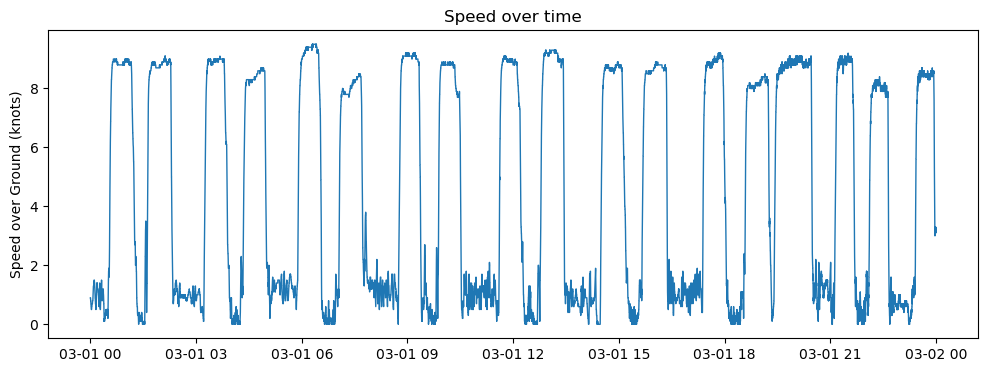

In [30]:
# Speed profile — with gap masking to avoid misleading lines across time gaps
GAP_TIME = 30  # minutes

vessel["dt_min"] = vessel["# Timestamp"].diff().dt.total_seconds() / 60

sog_plot = vessel["SOG"].copy()
sog_plot[vessel["dt_min"] > GAP_TIME] = np.nan

plt.figure(figsize=(12, 4))
plt.plot(vessel["# Timestamp"], sog_plot, linewidth=1)
plt.ylabel("Speed over Ground (knots)")
plt.title("Speed over time")
plt.show()

### Vessel Movement Analysis

Speed over ground (SOG) and step distance are plotted over time to characterise the vessel's movement pattern — identifying active transit periods, slow speeds, and stationary intervals.

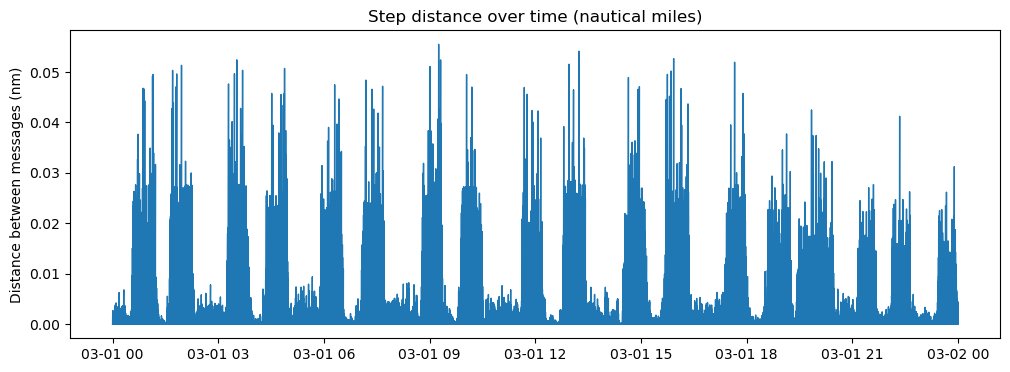

In [31]:
from geopy.distance import geodesic

# Distance between consecutive AIS points (nautical miles) using geopy
# 1 nautical mile = 1.852 km (IUGG definition)
def calculate_distance(row):
    if pd.isna(row['prev_lat']) or pd.isna(row['prev_lon']):
        return 0.0
    return geodesic((row['prev_lat'], row['prev_lon']), (row['Latitude'], row['Longitude'])).kilometers / 1.852

# dt_min already computed in the speed plot cell above

# Shift coordinates to get previous point
vessel['prev_lat'] = vessel['Latitude'].shift()
vessel['prev_lon'] = vessel['Longitude'].shift()

# Apply distance calculation
vessel["distance_nm"] = vessel.apply(calculate_distance, axis=1)

# Drop temporary columns
vessel = vessel.drop(columns=['prev_lat', 'prev_lon'])

# Mask across gaps to avoid misleading connections (same logic as speed plot)
dist_plot = vessel["distance_nm"].copy()
dist_plot[vessel["dt_min"] > GAP_TIME] = np.nan

plt.figure(figsize=(12, 4))
plt.plot(vessel["# Timestamp"], dist_plot, linewidth=1)
plt.ylabel("Distance between messages (nm)")
plt.title("Step distance over time (nautical miles)")
plt.show()

### Distance Calculation Method

The distance between consecutive AIS position reports is calculated using the geodesic formula, which accounts for the curvature of the Earth.

**Method:**
1. `geopy.distance.geodesic()` computes the great-circle distance in kilometres between consecutive GPS points
2. Result is converted to nautical miles by dividing by 1.852 (IUGG standard: 1 nm = 1.852 km)
3. Time differences between messages are used to mask across gaps (intervals > 30 min are broken)

**What the plots show:**
- **Speed plot**: Identifies when the vessel was in transit, slowing, or stationary
- **Distance plot**: Shows large step distances during fast transit and near-zero steps when stopped, in nautical miles

### Journey Segmentation

Each AIS message is classified into one of three states using a **hysteresis** approach, which reduces noise-driven state flickering:
- **Stop**: Smoothed speed below 2.5 knots → vessel is stationary
- **Moving**: Smoothed speed at or above 4.0 knots → vessel is in transit
- **Hysteresis band** (2.5–4.0 kn): State is inherited from the previous row, preventing rapid toggling
- **Gap**: Time interval to the previous message exceeds 30 minutes (label placed on the row after the gap)

A rolling average (window = 3) is applied to smooth out short-duration AIS speed jitter before thresholding.

In [32]:
# Hysteresis thresholds
STOP_KT  = 2.5   # below this → definitely stopped
MOVE_KT  = 4.0   # at or above this → definitely moving
GAP_TIME = 30    # minutes

# Light rolling average (window=3) to reduce AIS low-speed jitter.
# This is a pragmatic noise-reduction choice, not a scientifically validated model.
vessel["SOG_smooth"] = vessel["SOG"].rolling(window=3, min_periods=1).mean()

# --- Before-vs-after comparison baseline (computed BEFORE we overwrite "state") ---
old_state = np.where(vessel["SOG"] < 1.0, "stop", "moving")
old_transitions = (old_state[1:] != old_state[:-1]).sum()

# --- Gap-aware hysteresis segmentation ---

# 1. Identify gap boundaries (gap label marks the row AFTER the long interval)
is_gap = vessel["dt_min"] > GAP_TIME

# 2. Create continuous-block IDs — each gap starts a new block
vessel["block"] = is_gap.cumsum()

# 3. Assign definite states at threshold boundaries
#    Use object dtype so the column can hold both NaN and strings
vessel["state"] = pd.Series(np.nan, index=vessel.index, dtype=object)
vessel.loc[vessel["SOG_smooth"] < STOP_KT, "state"] = "stop"
vessel.loc[vessel["SOG_smooth"] >= MOVE_KT, "state"] = "moving"
# Rows in the band [2.5, 4.0) remain NaN — they inherit from the previous row

# 4. Forward-fill ONLY within each continuous block
#    This prevents state from leaking across time gaps
vessel["state"] = vessel.groupby("block")["state"].ffill()

# 5. Any remaining NaN (start of a block where SOG is in the band) defaults to "stop"
vessel["state"] = vessel["state"].fillna("stop")

# 6. Mark gap rows explicitly
vessel.loc[is_gap, "state"] = "gap"

# 7. Clean up helper column
vessel = vessel.drop(columns=["block"])

# Create segment IDs
vessel["segment_id"] = (vessel["state"] != vessel["state"].shift()).cumsum()

# Find journeys (high speed segments)
segment_stats = vessel.groupby("segment_id").agg({
    "state": "first",
    "SOG": "mean",
    "# Timestamp": ["min", "max"]
})

segment_stats.columns = ["state", "avg_speed", "start_time", "end_time"]
segment_stats["duration_min"] = (segment_stats["end_time"] - segment_stats["start_time"]).dt.total_seconds() / 60

# Assign journey IDs to fast segments
journeys = segment_stats[
    (segment_stats["state"] == "moving") & 
    (segment_stats["avg_speed"] >= MOVE_KT) &
    (segment_stats["duration_min"] >= 10)
].index

journey_map = {seg_id: i+1 for i, seg_id in enumerate(journeys)}
vessel["journey_id"] = vessel["segment_id"].map(journey_map)

# Ensure journey_id only applies to moving states (not leaked to gaps/stops)
vessel["journey_id"] = np.where(vessel["state"] == "moving", vessel["journey_id"], np.nan)

# --- Transition comparison ---
new_transitions = (vessel["state"] != vessel["state"].shift()).sum()
print(f"Old method (SOG < 1.0 kn, no smoothing): {old_transitions} transitions")
print(f"New method (hysteresis 2.5/4.0 kn):      {new_transitions} transitions")
if old_transitions > 0:
    print(f"Reduction: {old_transitions - new_transitions} fewer ({(1 - new_transitions/old_transitions)*100:.0f}%)")

print(f"\nFound {len(journeys)} journeys")
vessel["state"].value_counts()

Old method (SOG < 1.0 kn, no smoothing): 361 transitions
New method (hysteresis 2.5/4.0 kn):      36 transitions
Reduction: 325 fewer (90%)

Found 18 journeys


state
moving    31458
stop      27821
Name: count, dtype: int64

### Journey Segmentation Algorithm

Each AIS message is classified into a movement state using the following steps:

**Step 1: Define Thresholds**
- `STOP_KT = 2.5 knots`: Below this → vessel is definitely stopped
- `MOVE_KT = 4.0 knots`: At or above this → vessel is definitely moving
- Between 2.5 and 4.0 knots → **hysteresis band**: state is inherited from the previous row
- `GAP_TIME = 30 minutes`: If the interval since the previous message exceeds this, a gap is recorded (label placed on the row after the interval)

**Step 2: Smooth Speed**
- A rolling average (window = 3) is applied to reduce short-duration AIS speed jitter before thresholding
- This is a pragmatic noise-reduction step, not a maritime-validated model

**Step 3: Gap-Aware Hysteresis**
- Definite states are assigned where speed is clearly above or below the thresholds
- Within the hysteresis band, state is forward-filled only within continuous time blocks (not across gaps)
- If a block starts in the band with no prior state available, it defaults to "stop"
- Gap rows are then labelled explicitly

**Step 4: Create Segments**
- Consecutive rows sharing the same state are grouped into a segment
- Each state change creates a new segment with a unique ID

**Step 5: Identify Journeys**
- Only "moving" segments are considered
- A segment qualifies as a journey if: average speed ≥ 4.0 kn **and** duration ≥ 10 minutes
- Qualifying segments are assigned sequential journey IDs (1, 2, 3…)
- Journey IDs are not propagated to stop or gap rows

**Step 6: Validate**
- Old (simple threshold) vs new (hysteresis) transition counts are compared to confirm the method reduces implausible state oscillation

In [33]:
# Show the journeys we found with detailed information
from geopy.distance import geodesic

journey_analysis = []
for journey_id in vessel["journey_id"].dropna().unique():
    journey_data = vessel[vessel["journey_id"] == journey_id].copy()
    
    # Calculate journey details
    start_time = journey_data["# Timestamp"].min()
    end_time = journey_data["# Timestamp"].max()
    duration_min = (end_time - start_time).total_seconds() / 60
    avg_speed = journey_data["SOG"].mean()
    max_speed = journey_data["SOG"].max()
    
    # Calculate total distance in nautical miles
    total_distance = 0
    for i in range(1, len(journey_data)):
        prev_point = (journey_data.iloc[i-1]["Latitude"], journey_data.iloc[i-1]["Longitude"])
        curr_point = (journey_data.iloc[i]["Latitude"], journey_data.iloc[i]["Longitude"])
        total_distance += geodesic(prev_point, curr_point).kilometers / 1.852
    
    # Start and end locations
    start_lat = journey_data.iloc[0]["Latitude"]
    start_lon = journey_data.iloc[0]["Longitude"]
    end_lat = journey_data.iloc[-1]["Latitude"]
    end_lon = journey_data.iloc[-1]["Longitude"]
    
    journey_analysis.append({
        "Journey_ID": int(journey_id),
        "Start_Time": start_time,
        "End_Time": end_time,
        "Duration_min": round(duration_min, 1),
        "Distance_nm": round(total_distance, 2),
        "Avg_Speed_kn": round(avg_speed, 1),
        "Max_Speed_kn": round(max_speed, 1),
        "Start_Lat": round(start_lat, 4),
        "Start_Lon": round(start_lon, 4),
        "End_Lat": round(end_lat, 4),
        "End_Lon": round(end_lon, 4)
    })

journey_df = pd.DataFrame(journey_analysis)
print(f"Found {len(journey_df)} distinct journeys:")
journey_df

Found 18 distinct journeys:


,Journey_ID,Start_Time,End_Time,Duration_min,Distance_nm,Avg_Speed_kn,Max_Speed_kn,Start_Lat,Start_Lon,End_Lat,End_Lon
0,1,2025-03-01 00:33:09,2025-03-01 01:16:30,43.4,6.06,8.1,9.0,56.6676,8.0126,56.6941,8.1863
1,2,2025-03-01 01:37:16,2025-03-01 02:19:20,42.1,6.07,8.5,9.1,56.6945,8.1852,56.6685,8.0130
2,3,2025-03-01 03:14:50,2025-03-01 03:54:05,39.2,5.50,8.3,9.1,56.6826,8.0218,56.6941,8.1855
3,4,2025-03-01 04:20:57,2025-03-01 04:59:43,38.8,5.24,8.0,8.7,56.6946,8.1859,56.6860,8.0289
4,5,2025-03-01 05:53:59,2025-03-01 06:33:23,39.4,5.83,8.8,9.5,56.6727,8.0171,56.6941,8.1876
5,6,2025-03-01 07:03:54,2025-03-01 07:43:59,40.1,5.35,7.7,8.5,56.6949,8.1869,56.6868,8.0299
6,7,2025-03-01 08:46:08,2025-03-01 09:22:38,36.5,5.39,8.6,9.2,56.6815,8.0288,56.6942,8.1867
7,8,2025-03-01 09:53:13,2025-03-01 10:31:03,37.8,5.30,8.2,8.9,56.6943,8.1860,56.6805,8.0287
8,9,2025-03-01 11:36:50,2025-03-01 12:15:02,38.2,5.32,8.3,9.1,56.6806,8.0294,56.6944,8.1862
9,10,2025-03-01 12:47:17,2025-03-01 13:27:05,39.8,5.92,8.8,9.3,56.6938,8.1854,56.6763,8.0107


### Detailed Journey Analysis

Each identified journey is summarised with the following attributes:

1. **Temporal extent**: Start time, end time, and total duration
2. **Distance**: Cumulative geodesic distance between consecutive GPS points, reported in nautical miles (÷ 1.852 km/nm)
3. **Speed statistics**: Average and maximum SOG during the journey
4. **Geographic endpoints**: Start and end coordinates

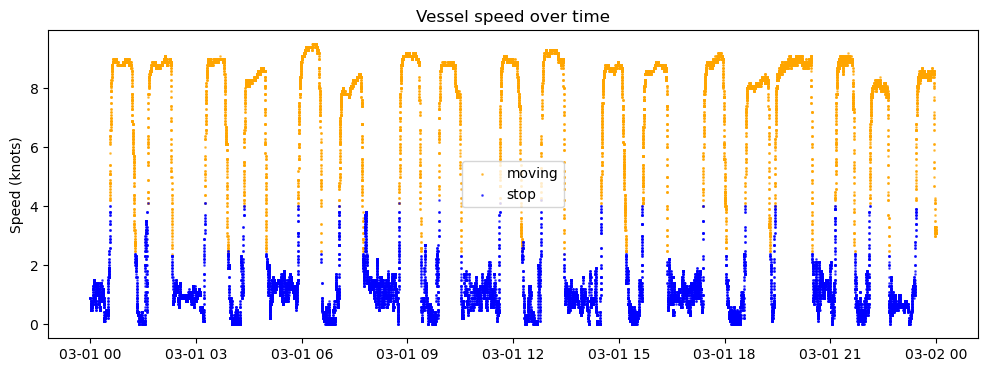

In [34]:
# Plot speed by state
plt.figure(figsize=(12, 4))

colors = {"moving": "orange", "stop": "blue", "gap": "red"}
for state, group in vessel.groupby("state"):
    plt.scatter(group["# Timestamp"], group["SOG"], c=colors[state], label=state, alpha=0.6, s=1)

plt.legend()
plt.ylabel("Speed (knots)")
plt.title("Vessel speed over time")
plt.show()

### State Classification — Visual Validation

Speed over ground is plotted and colour-coded by assigned state (moving, stop, gap) to visually verify that the hysteresis segmentation produces sensible results.

### Scope of the Map: Single-Vessel Analysis

The map displays the track and derived analytics for **one vessel only**, extracted from a dataset containing hundreds of ships.

**Vessel selection process:**
1. All AIS messages with (0,0) placeholder coordinates are removed
2. Vessels are ranked by total number of valid AIS messages
3. The most active vessel — `moving_counts.index[0]` — is selected automatically

More messages produce more GPS positions, yielding a richer and more reliable analysis.

**Selected vessel for this dataset:**

| Field | Value |
|-------|-------|
| Vessel name | FREJA R |
| MMSI | 219313000 |
| Ship type | Undefined (likely fishing) |
| AIS messages | ~59,000 (full day) |
| Journeys identified | 18 |

To analyse a different vessel, change `moving_counts.index[0]` to `moving_counts.index[1]` (second busiest), `index[2]` (third busiest), and so on, then re-run all subsequent cells.

### Reference Port Definitions and Stop Cluster Classification

Stop events are compared against a manually curated list of known ports in the vessel's operating area (north-west Jutland / Limfjord, Denmark). Coordinates are sourced from publicly available nautical charts.

A stop cluster is classified as **Near port** if its mean position is within 2 nautical miles of a reference port, and **Offshore** otherwise.

This replaces the previous approach of inferring a "home port" from the largest stop cluster, which is not reliable when a vessel makes multiple offshore stops of similar duration.

In [35]:
# ── Reference ports — manually verified coordinates, NW Jutland / Limfjord ──
from geopy.distance import geodesic

REFERENCE_PORTS = pd.DataFrame([
    {"name": "Thyborøn",    "lat": 56.7096, "lon": 8.2126},
    {"name": "Harboøre",    "lat": 56.6254, "lon": 8.1760},
    {"name": "Lemvig",      "lat": 56.5498, "lon": 8.3076},
    {"name": "Struer",      "lat": 56.4923, "lon": 8.5863},
    {"name": "Nykøbing M",  "lat": 56.7952, "lon": 8.8555},
])

print("Reference ports:")
print(REFERENCE_PORTS.to_string(index=False))

# ── Nearest-port assignment for each significant stop cluster ─────────────────
OFFSHORE_THRESHOLD_NM = 2.0   # stops closer than this are "Near port"

stops_ref = vessel[vessel["state"] == "stop"].copy()
stops_ref["time_gap"] = stops_ref["# Timestamp"].diff().dt.total_seconds() / 60
stop_grp_ref = stops_ref.groupby((stops_ref["time_gap"] > 5).cumsum())

cluster_port_rows = []
for gid, sg in stop_grp_ref:
    if len(sg) < 3:
        continue
    clat = sg["Latitude"].mean()
    clon = sg["Longitude"].mean()
    dur  = (sg["# Timestamp"].max() - sg["# Timestamp"].min()).total_seconds() / 60

    dists = REFERENCE_PORTS.apply(
        lambda r: geodesic((clat, clon), (r["lat"], r["lon"])).nautical, axis=1
    )
    nearest_idx  = dists.idxmin()
    nearest_port = REFERENCE_PORTS.loc[nearest_idx, "name"]
    nearest_dist = round(dists.min(), 2)

    cluster_port_rows.append({
        "cluster_id":     gid,
        "mean_lat":       round(clat, 4),
        "mean_lon":       round(clon, 4),
        "duration_min":   round(dur, 1),
        "n_msgs":         len(sg),
        "nearest_port":   nearest_port,
        "dist_nm":        nearest_dist,
        "classification": "Near port" if nearest_dist < OFFSHORE_THRESHOLD_NM else "Offshore",
    })

cluster_port_df = pd.DataFrame(cluster_port_rows)

# ── Validation ────────────────────────────────────────────────────────────────
assert cluster_port_df["nearest_port"].notna().all(), \
    "Some stop clusters have no port assignment — check REFERENCE_PORTS coverage."

n_near     = (cluster_port_df["classification"] == "Near port").sum()
n_offshore = (cluster_port_df["classification"] == "Offshore").sum()
print(f"\nTotal significant stop clusters: {len(cluster_port_df)}")
print(f"  Near port  (< {OFFSHORE_THRESHOLD_NM} nm):  {n_near}")
print(f"  Offshore   (≥ {OFFSHORE_THRESHOLD_NM} nm):  {n_offshore}")
print(f"  All have a nearest-port assignment: ✓")

print(f"\nStop cluster summary:")
print(cluster_port_df[
    ["cluster_id", "mean_lat", "mean_lon", "duration_min",
     "nearest_port", "dist_nm", "classification"]
].to_string(index=False))

Reference ports:
      name     lat    lon
  Thyborøn 56.7096 8.2126
  Harboøre 56.6254 8.1760
    Lemvig 56.5498 8.3076
    Struer 56.4923 8.5863
Nykøbing M 56.7952 8.8555

Total significant stop clusters: 18
  Near port  (< 2.0 nm):  7
  Offshore   (≥ 2.0 nm):  11
  All have a nearest-port assignment: ✓

Stop cluster summary:
 cluster_id  mean_lat  mean_lon  duration_min nearest_port  dist_nm classification
          0   56.6704    8.0120          33.0     Harboøre     6.07       Offshore
          1   56.6942    8.1887          20.7     Thyborøn     1.22      Near port
          2   56.6760    8.0156          55.5     Harboøre     6.12       Offshore
          3   56.6944    8.1886          26.8     Thyborøn     1.21      Near port
          4   56.6807    8.0206          54.2     Harboøre     6.13       Offshore
          5   56.6947    8.1890          30.5     Thyborøn     1.19      Near port
          6   56.6828    8.0258          62.1     Harboøre     6.05       Offshore
      

In [43]:
import folium
from folium.plugins import MiniMap, MeasureControl, MousePosition

# ── Vessel metadata ───────────────────────────────────────────────────────────
vessel_name = vessel["Name"].dropna().iloc[0] if vessel["Name"].notna().any() else "Unknown"
vessel_type = vessel["Ship type"].dropna().iloc[0] if "Ship type" in vessel.columns and vessel["Ship type"].notna().any() else "Unknown"
n_journeys  = int(vessel["journey_id"].dropna().nunique())
total_pts   = len(vessel)

# ── Colour scheme ─────────────────────────────────────────────────────────────
JOURNEY_COLOR = "#1b4f72"   # navy blue — all journeys same colour
TRACK_COLOR   = "#aab7c4"   # light grey-blue for background track
STOP_COLOR    = "#c0392b"   # muted red for stops
START_COLOR   = "#27ae60"   # green for start markers
END_COLOR     = "#c0392b"   # red for end markers
PORT_COLOR    = "#8e44ad"   # purple for reference port markers

# ── Base map ──────────────────────────────────────────────────────────────────
center_lat = vessel["Latitude"].mean()
center_lon = vessel["Longitude"].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=8,
    tiles=None,
    control_scale=True,
)

folium.TileLayer("CartoDB positron",    name="Light",          control=True).add_to(m)
folium.TileLayer("CartoDB dark_matter", name="Dark",           control=True).add_to(m)
folium.TileLayer("OpenStreetMap",       name="OpenStreetMap",  control=True).add_to(m)

fg_track    = folium.FeatureGroup(name="Full Track",         show=True).add_to(m)
fg_journeys = folium.FeatureGroup(name="Journeys",           show=True).add_to(m)
fg_labels   = folium.FeatureGroup(name="Journey Labels",     show=True).add_to(m)
fg_stops    = folium.FeatureGroup(name="Stop Locations",     show=True).add_to(m)
fg_ports    = folium.FeatureGroup(name="Reference Ports",    show=True).add_to(m)

# ── 1. Full vessel track — gap-aware (one PolyLine per contiguous chunk) ──────
# Split wherever dt_min > GAP_TIME to avoid straight lines across large gaps.
track_chunk_id = vessel["dt_min"].gt(GAP_TIME).cumsum()
track_chunks = [
    list(zip(chunk["Latitude"], chunk["Longitude"]))
    for _, chunk in vessel.groupby(track_chunk_id)
    if len(chunk) >= 2
]
for chunk_pts in track_chunks:
    folium.PolyLine(
        chunk_pts,
        color=TRACK_COLOR,
        weight=1.5,
        opacity=0.4,
        dash_array="6 4",
        tooltip="Full vessel track",
    ).add_to(fg_track)
print(f"Gap-aware track: {len(track_chunks)} contiguous chunks "
      f"(split at dt_min > {GAP_TIME} min)")

# ── Helper: numbered circle marker ───────────────────────────────────────────
def numbered_marker(location, number, bg_color, tooltip_text, popup_html):
    """Create a small circle with a journey number inside."""
    icon_html = f"""
    <div style="
        width:22px; height:22px; border-radius:50%;
        background:{bg_color}; border:2px solid #fff;
        color:#fff; font-family:Segoe UI,Arial,sans-serif;
        font-size:11px; font-weight:700;
        display:flex; align-items:center; justify-content:center;
        box-shadow:0 1px 4px rgba(0,0,0,0.4);
        transform:translate(-11px,-11px);">
        {number}
    </div>"""
    return folium.Marker(
        location,
        tooltip=tooltip_text,
        popup=folium.Popup(popup_html, max_width=260),
        icon=folium.DivIcon(html=icon_html, icon_size=(22, 22), icon_anchor=(0, 0)),
    )

# ── 2. Journey lines + numbered start/end markers ────────────────────────────
sorted_jids = sorted(vessel["journey_id"].dropna().unique())

for idx, jid in enumerate(sorted_jids):
    jnum   = int(jid)
    jdata  = vessel[vessel["journey_id"] == jid]
    jtrack = list(zip(jdata["Latitude"], jdata["Longitude"]))

    dur_min  = (jdata["# Timestamp"].max() - jdata["# Timestamp"].min()).total_seconds() / 60
    avg_spd  = jdata["SOG"].mean()
    max_spd  = jdata["SOG"].max()
    dist_nm  = journey_df.loc[journey_df["Journey_ID"] == jnum, "Distance_nm"].values
    dist_str = f"{dist_nm[0]:.1f} nm" if len(dist_nm) else "—"

    popup_html = f"""
    <div style="font-family:Segoe UI,Helvetica,Arial,sans-serif; min-width:190px;">
        <h4 style="margin:0 0 6px; color:{JOURNEY_COLOR};
                   border-bottom:2px solid {JOURNEY_COLOR}; padding-bottom:4px;">
            Journey {jnum}</h4>
        <table style="font-size:12px; border-collapse:collapse;">
            <tr><td style="padding:2px 8px 2px 0; color:#888;">Start</td>
                <td><b>{jdata.iloc[0]['# Timestamp'].strftime('%H:%M:%S')}</b></td></tr>
            <tr><td style="padding:2px 8px 2px 0; color:#888;">End</td>
                <td><b>{jdata.iloc[-1]['# Timestamp'].strftime('%H:%M:%S')}</b></td></tr>
            <tr><td style="padding:2px 8px 2px 0; color:#888;">Duration</td>
                <td>{dur_min:.0f} min</td></tr>
            <tr><td style="padding:2px 8px 2px 0; color:#888;">Distance</td>
                <td>{dist_str}</td></tr>
            <tr><td style="padding:2px 8px 2px 0; color:#888;">Avg speed</td>
                <td>{avg_spd:.1f} kn</td></tr>
            <tr><td style="padding:2px 8px 2px 0; color:#888;">Max speed</td>
                <td>{max_spd:.1f} kn</td></tr>
        </table>
    </div>"""

    # Journey line — single consistent colour
    folium.PolyLine(
        jtrack,
        color=JOURNEY_COLOR,
        weight=4,
        opacity=0.8,
        popup=folium.Popup(popup_html, max_width=260),
        tooltip=f"Journey {jnum}  ·  {dur_min:.0f} min  ·  {avg_spd:.1f} kn avg",
    ).add_to(fg_journeys)

    # Numbered start marker (green)
    numbered_marker(
        jtrack[0], jnum, START_COLOR,
        tooltip_text=f"J{jnum} start · {jdata.iloc[0]['# Timestamp'].strftime('%H:%M')}",
        popup_html=popup_html,
    ).add_to(fg_labels)

    # Numbered end marker (red)
    numbered_marker(
        jtrack[-1], jnum, END_COLOR,
        tooltip_text=f"J{jnum} end · {jdata.iloc[-1]['# Timestamp'].strftime('%H:%M')}",
        popup_html=popup_html,
    ).add_to(fg_labels)

# ── 3. Stop locations ─────────────────────────────────────────────────────────
stops = vessel[vessel["state"] == "stop"].copy()
stops["time_gap"] = stops["# Timestamp"].diff().dt.total_seconds() / 60
stop_groups = stops.groupby((stops["time_gap"] > 5).cumsum())

for gid, sg in stop_groups:
    if len(sg) < 3:
        continue
    clat = sg["Latitude"].mean()
    clon = sg["Longitude"].mean()
    dur  = (sg["# Timestamp"].max() - sg["# Timestamp"].min()).total_seconds() / 60

    radius = max(4, min(14, int(3 * np.log2(dur + 1))))

    stop_popup = f"""
    <div style="font-family:Segoe UI,Helvetica,Arial,sans-serif; min-width:160px;">
        <h4 style="margin:0 0 6px; color:{STOP_COLOR};
                   border-bottom:2px solid {STOP_COLOR}; padding-bottom:4px;">
            ⚓ Stop</h4>
        <table style="font-size:12px; border-collapse:collapse;">
            <tr><td style="padding:2px 8px 2px 0; color:#888;">From</td>
                <td>{sg.iloc[0]['# Timestamp'].strftime('%H:%M:%S')}</td></tr>
            <tr><td style="padding:2px 8px 2px 0; color:#888;">To</td>
                <td>{sg.iloc[-1]['# Timestamp'].strftime('%H:%M:%S')}</td></tr>
            <tr><td style="padding:2px 8px 2px 0; color:#888;">Duration</td>
                <td>{dur:.0f} min</td></tr>
            <tr><td style="padding:2px 8px 2px 0; color:#888;">AIS msgs</td>
                <td>{len(sg)}</td></tr>
        </table>
    </div>"""

    folium.CircleMarker(
        [clat, clon],
        radius=radius,
        color=STOP_COLOR,
        fill=True,
        fill_color=STOP_COLOR,
        fill_opacity=0.45,
        tooltip=f"Stop · {dur:.0f} min · {len(sg)} pts",
        popup=folium.Popup(stop_popup, max_width=220),
    ).add_to(fg_stops)

n_stops = len([g for _, g in stop_groups if len(g) >= 3])

# ── 4. Reference port markers ─────────────────────────────────────────────────
for _, port_row in REFERENCE_PORTS.iterrows():
    port_popup = f"""
    <div style="font-family:Segoe UI,Helvetica,Arial,sans-serif; min-width:140px;">
        <h4 style="margin:0 0 6px; color:{PORT_COLOR};
                   border-bottom:2px solid {PORT_COLOR}; padding-bottom:4px;">
            ⚓ {port_row['name']}</h4>
        <table style="font-size:12px; border-collapse:collapse;">
            <tr><td style="padding:2px 8px 2px 0; color:#888;">Lat</td>
                <td>{port_row['lat']:.4f}</td></tr>
            <tr><td style="padding:2px 8px 2px 0; color:#888;">Lon</td>
                <td>{port_row['lon']:.4f}</td></tr>
        </table>
    </div>"""
    port_icon_html = f"""
    <div style="
        background:{PORT_COLOR}; border:2px solid #fff; border-radius:3px;
        color:#fff; font-family:Segoe UI,Arial,sans-serif;
        font-size:10px; font-weight:700; white-space:nowrap;
        padding:2px 6px; box-shadow:0 1px 4px rgba(0,0,0,0.4);
        transform:translate(-50%,-100%);">
        ⚓ {port_row['name']}
    </div>"""
    folium.Marker(
        [port_row["lat"], port_row["lon"]],
        tooltip=port_row["name"],
        popup=folium.Popup(port_popup, max_width=200),
        icon=folium.DivIcon(html=port_icon_html, icon_size=(120, 24), icon_anchor=(0, 0)),
    ).add_to(fg_ports)

# ── 5. Layer control ──────────────────────────────────────────────────────────
folium.LayerControl(collapsed=False).add_to(m)

# ── 6. Plugins ────────────────────────────────────────────────────────────────
MiniMap(tile_layer="CartoDB positron", toggle_display=True,
        width=120, height=120, minimized=False).add_to(m)
MeasureControl(primary_length_unit="nautical_miles",
               secondary_length_unit="kilometers",
               primary_area_unit="sqmeters").add_to(m)
MousePosition(position="bottomright", separator=" | ",
              prefix="Lat/Lon:", num_digits=5).add_to(m)

# ── 7. Legend ─────────────────────────────────────────────────────────────────
legend_html = f"""
<div id="ais-legend" style="
    position:fixed; bottom:30px; left:12px; z-index:9999;
    background:rgba(255,255,255,0.95); border:1px solid #ccc;
    border-radius:6px; padding:12px 16px; box-shadow:0 2px 8px rgba(0,0,0,0.18);
    font-family:Segoe UI,Helvetica,Arial,sans-serif; max-width:220px;
    line-height:1.5;">

    <div style="font-size:13px;font-weight:700;margin-bottom:8px;
                border-bottom:1px solid #ddd;padding-bottom:6px;">
        🚢 {vessel_name}
        <span style="font-weight:400;font-size:11px;color:#888;display:block;">
            MMSI {SELECTED_MMSI} · {vessel_type}</span>
    </div>

    <div style="display:flex;align-items:center;margin:4px 0;">
        <span style="display:inline-block;width:28px;height:0;
              border-top:2px dashed {TRACK_COLOR};margin-right:8px;"></span>
        <span style="font-size:11px;">Full track ({total_pts:,} pts)</span>
    </div>

    <div style="display:flex;align-items:center;margin:4px 0;">
        <span style="display:inline-block;width:28px;height:4px;
              background:{JOURNEY_COLOR};border-radius:2px;margin-right:8px;"></span>
        <span style="font-size:11px;">Journey ({n_journeys} total)</span>
    </div>

    <div style="display:flex;align-items:center;margin:4px 0;">
        <span style="display:inline-flex;align-items:center;justify-content:center;
              width:18px;height:18px;border-radius:50%;
              background:{START_COLOR};color:#fff;font-size:9px;
              font-weight:700;margin-right:8px;">n</span>
        <span style="font-size:11px;">Journey start (numbered)</span>
    </div>

    <div style="display:flex;align-items:center;margin:4px 0;">
        <span style="display:inline-flex;align-items:center;justify-content:center;
              width:18px;height:18px;border-radius:50%;
              background:{END_COLOR};color:#fff;font-size:9px;
              font-weight:700;margin-right:8px;">n</span>
        <span style="font-size:11px;">Journey end (numbered)</span>
    </div>

    <div style="display:flex;align-items:center;margin:4px 0;">
        <span style="display:inline-block;width:14px;height:14px;
              border-radius:50%;background:{STOP_COLOR};opacity:0.45;
              border:2px solid {STOP_COLOR};margin-right:8px;"></span>
        <span style="font-size:11px;">Stop (size ∝ duration)</span>
    </div>

    <div style="display:flex;align-items:center;margin:4px 0;">
        <span style="display:inline-block;width:14px;height:14px;
              background:{PORT_COLOR};border-radius:2px;
              border:2px solid #fff;margin-right:8px;"></span>
        <span style="font-size:11px;">Reference port</span>
    </div>

</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# ── 8. Title bar ──────────────────────────────────────────────────────────────
title_html = f"""
<div style="
    position:fixed; top:10px; left:50%; transform:translateX(-50%); z-index:9999;
    background:rgba(255,255,255,0.92); border:1px solid #ccc; border-radius:6px;
    padding:6px 20px; box-shadow:0 2px 6px rgba(0,0,0,0.15);
    font-family:Segoe UI,Helvetica,Arial,sans-serif; font-size:14px; font-weight:600;">
    AIS Vessel Track — {vessel_name} ({SELECTED_MMSI}) —
    {vessel['# Timestamp'].min().strftime('%Y-%m-%d')}
</div>
"""
m.get_root().html.add_child(folium.Element(title_html))

# ── Save ──────────────────────────────────────────────────────────────────────
m.save("vessel_map.html")
print(f"Map saved → vessel_map.html")
print(f"  {n_journeys} journeys · {n_stops} stops · {total_pts:,} AIS points")
print(f"  Full track: {len(track_chunks)} gap-split chunks · {len(REFERENCE_PORTS)} reference ports plotted")

m


Gap-aware track: 1 contiguous chunks (split at dt_min > 30 min)
Map saved → vessel_map.html
  18 journeys · 18 stops · 59,279 AIS points
  Full track: 1 gap-split chunks · 5 reference ports plotted


### Stop Location Analysis: Port vs Sea

The stop detection algorithm is purely kinematic — it classifies any period with SOG below 2.5 knots as a stop, regardless of geographic position. This section investigates whether detected stops occur at port or offshore, and examines the possible reasons for mid-sea stops.

In [42]:
# ── Investigate mid-sea stops ────────────────────────────────────────────────
# Our stop detection is purely speed-based (SOG_smooth < 2.5 kn).
# This cell checks WHY some stops appear offshore.

from geopy.distance import geodesic

# Reconstruct stop groups (same logic as map cell)
stops_diag = vessel[vessel["state"] == "stop"].copy()
stops_diag["time_gap"] = stops_diag["# Timestamp"].diff().dt.total_seconds() / 60
stop_groups_diag = stops_diag.groupby((stops_diag["time_gap"] > 5).cumsum())

# Approximate port/coast reference: use the most common stop cluster as "port"
# (the largest stop cluster by point count is likely the home port)
biggest_cluster = max(
    ((gid, sg) for gid, sg in stop_groups_diag if len(sg) >= 3),
    key=lambda x: len(x[1])
)
port_lat = biggest_cluster[1]["Latitude"].mean()
port_lon = biggest_cluster[1]["Longitude"].mean()
print(f"Estimated home port location: ({port_lat:.4f}, {port_lon:.4f})")

# Analyse each stop
stop_analysis = []
for gid, sg in stop_groups_diag:
    if len(sg) < 3:
        continue
    clat = sg["Latitude"].mean()
    clon = sg["Longitude"].mean()
    dur  = (sg["# Timestamp"].max() - sg["# Timestamp"].min()).total_seconds() / 60
    dist_from_port = geodesic((port_lat, port_lon), (clat, clon)).nautical

    # Check navigational status if available
    nav_statuses = sg["Navigational status"].dropna().unique().tolist() if "Navigational status" in sg.columns else []

    # Check if stop is near a gap boundary (potential AIS artefact)
    stop_indices = sg.index
    near_gap = vessel.loc[stop_indices, "dt_min"].max() if "dt_min" in vessel.columns else 0

    # Average raw SOG during this "stop" (before smoothing)
    avg_raw_sog = sg["SOG"].mean()
    max_raw_sog = sg["SOG"].max()

    stop_analysis.append({
        "start_time": sg.iloc[0]["# Timestamp"].strftime("%H:%M"),
        "end_time": sg.iloc[-1]["# Timestamp"].strftime("%H:%M"),
        "duration_min": round(dur, 1),
        "lat": round(clat, 4),
        "lon": round(clon, 4),
        "dist_from_port_nm": round(dist_from_port, 1),
        "avg_SOG": round(avg_raw_sog, 2),
        "max_SOG": round(max_raw_sog, 2),
        "n_msgs": len(sg),
        "nav_status": ", ".join(nav_statuses) if nav_statuses else "—",
        "max_dt_min": round(near_gap, 1) if near_gap else 0,
    })

stop_df = pd.DataFrame(stop_analysis)

# Classify stops
stop_df["location"] = np.where(stop_df["dist_from_port_nm"] < 1.0, "At port", "At sea")

print(f"\n{'='*60}")
print(f"STOP ANALYSIS — {vessel_name} (MMSI {SELECTED_MMSI})")
print(f"{'='*60}")
print(f"Total significant stops: {len(stop_df)}")
print(f"  At port (< 1 nm from estimated port): {(stop_df['location'] == 'At port').sum()}")
print(f"  At sea  (≥ 1 nm from estimated port): {(stop_df['location'] == 'At sea').sum()}")

# Show the at-sea stops
sea_stops = stop_df[stop_df["location"] == "At sea"]
if len(sea_stops) > 0:
    print(f"\n── At-sea stops detail ──")
    print(f"  Distances from port: {sea_stops['dist_from_port_nm'].min():.1f} – {sea_stops['dist_from_port_nm'].max():.1f} nm")
    print(f"  Durations: {sea_stops['duration_min'].min():.0f} – {sea_stops['duration_min'].max():.0f} min")
    print(f"  Avg raw SOG range: {sea_stops['avg_SOG'].min():.2f} – {sea_stops['avg_SOG'].max():.2f} kn")
    print(f"  Nav statuses seen: {sea_stops['nav_status'].unique().tolist()}")

print(f"\n── Root cause analysis ──")
print("Our stop detection is purely KINEMATIC (speed < 2.5 kn).")
print("It has NO spatial awareness — it cannot distinguish:")
print("  1. Port stops (vessel berthed/anchored at port)")
print("  2. Drifting/loitering at sea (waiting for berth, weather)")
print("  3. Fishing operations (hauling nets = low speed)")
print("  4. AIS artefacts (signal loss → gap → low-speed readings at boundaries)")

stop_df

Estimated home port location: (56.6828, 8.0258)

STOP ANALYSIS — FREJA R (MMSI 219313000)
Total significant stops: 18
  At port (< 1 nm from estimated port): 8
  At sea  (≥ 1 nm from estimated port): 10

── At-sea stops detail ──
  Distances from port: 5.4 – 9.9 nm
  Durations: 21 – 46 min
  Avg raw SOG range: 0.52 – 1.22 kn
  Nav statuses seen: ['Under way using engine']

── Root cause analysis ──
Our stop detection is purely KINEMATIC (speed < 2.5 kn).
It has NO spatial awareness — it cannot distinguish:
  1. Port stops (vessel berthed/anchored at port)
  2. Drifting/loitering at sea (waiting for berth, weather)
  3. Fishing operations (hauling nets = low speed)
  4. AIS artefacts (signal loss → gap → low-speed readings at boundaries)


,start_time,end_time,duration_min,lat,lon,dist_from_port_nm,avg_SOG,max_SOG,n_msgs,nav_status,max_dt_min,location
0,00:00,00:33,33.0,56.6704,8.0120,0.9,0.92,4.0,1346,Under way using engine,0.3,At port
1,01:16,01:37,20.7,56.6942,8.1887,5.4,0.88,4.1,872,Under way using engine,0.4,At sea
2,02:19,03:14,55.5,56.6760,8.0156,0.5,0.98,4.1,2129,Under way using engine,0.4,At port
3,03:54,04:20,26.8,56.6944,8.1886,5.4,0.73,4.0,941,Under way using engine,0.3,At sea
4,04:59,05:53,54.2,56.6807,8.0206,0.2,1.26,4.0,2501,Under way using engine,0.3,At port
5,06:33,07:03,30.5,56.6947,8.1890,5.4,0.52,4.0,1479,Under way using engine,0.4,At sea
6,07:44,08:46,62.1,56.6828,8.0258,0.0,1.38,4.1,2674,Under way using engine,0.5,At port
7,09:22,09:53,30.4,56.6947,8.1884,5.4,0.78,4.2,1028,Under way using engine,0.3,At sea
8,10:31,11:36,65.7,56.6811,8.0263,0.1,0.99,4.1,2007,Under way using engine,0.4,At port
9,12:15,12:47,32.2,56.6944,8.1886,5.4,0.71,4.2,1134,Under way using engine,0.3,At sea


### Speed comparison: Port stops vs Sea stops

**The question:** When the vessel stops, does it behave differently at port compared to at sea?

**Why this matters:**
- If sea stops have **much higher speeds** than port stops, they might just be the vessel slowing down briefly (not a real stop)
- If both have **similar low speeds**, the sea stops are genuine — the vessel truly stops out at sea

**How we check:**
1. Take every AIS message where the vessel is in "stop" state
2. Label each stop as **"At port"** (within 1 nautical mile of estimated home port) or **"At sea"** (farther away)
3. Compare the speed (SOG) distributions side by side

**What the 4 plots show:**
| Plot | What it tells you |
|------|-------------------|
| **Histogram** (top-left) | Shape of the speed distribution — are port and sea stops similar? |
| **Box plot** (top-right) | Median, spread, and outliers at a glance |
| **Timeline** (bottom-left) | When during the day port vs sea stops happen |
| **Duration vs Speed** (bottom-right) | Do longer stops have lower speed? (they should) |

 SPEED COMPARISON: PORT STOPS vs SEA STOPS
 Vessel: FREJA R (MMSI 219313000)

  ── At port (8 stop events, 15,281 AIS messages) ──
     SOG mean:   1.09 kn
     SOG median: 1.00 kn
     SOG std:    0.54 kn
     SOG min:    0.00 kn
     SOG max:    4.10 kn
     Percentiles: P25=0.80  P50=1.00  P75=1.30  P90=1.60  P95=1.90

  ── At sea (10 stop events, 12,540 AIS messages) ──
     SOG mean:   0.78 kn
     SOG median: 0.60 kn
     SOG std:    0.72 kn
     SOG min:    0.00 kn
     SOG max:    4.20 kn
     Percentiles: P25=0.20  P50=0.60  P75=1.10  P90=1.80  P95=2.20



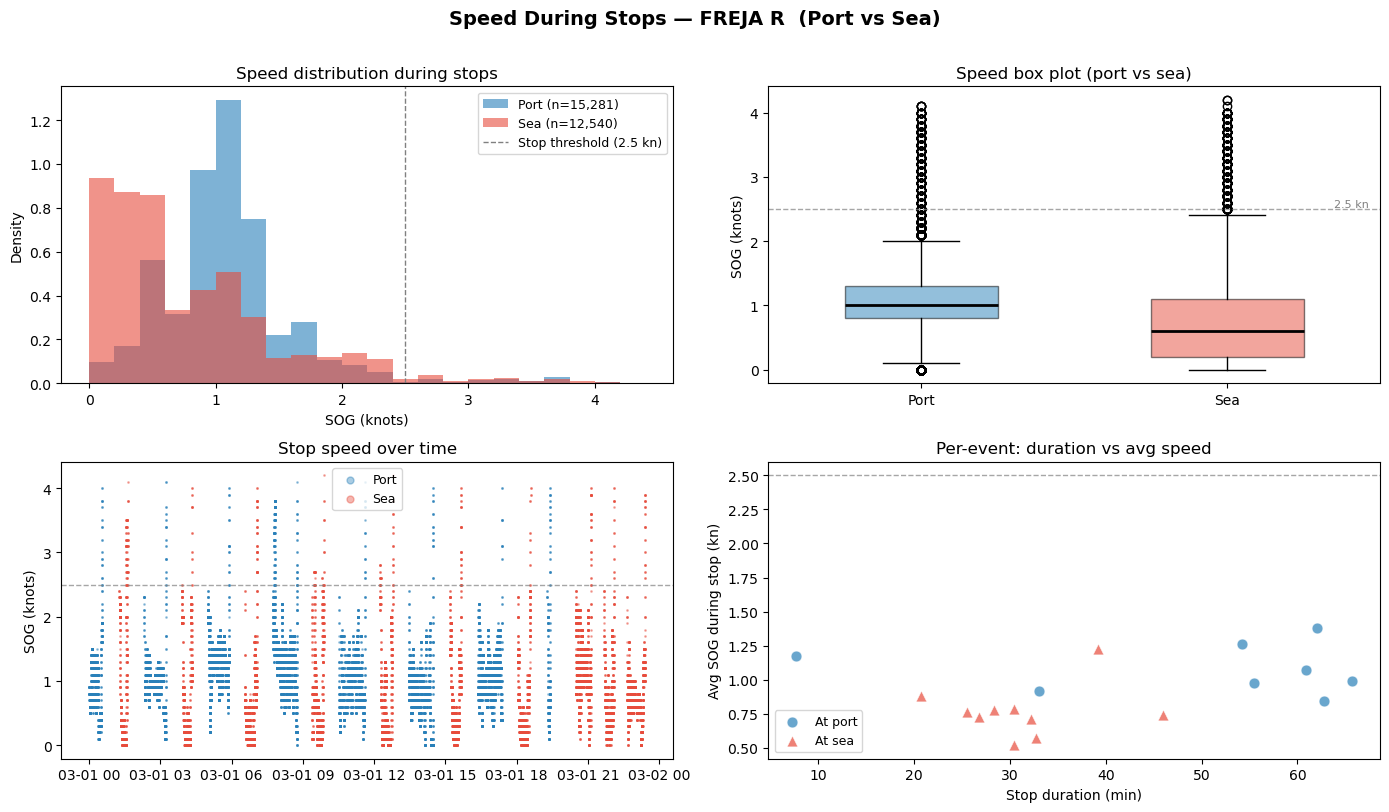


── Key finding ──
Port stop avg SOG: 1.09 kn    Sea stop avg SOG: 0.78 kn
→ Speed profiles are SIMILAR — both are genuine low-speed events.
  The sea stops are NOT AIS artefacts; the vessel actually slows/stops at sea.
  Most likely: fishing ops, drifting, or loitering at a work site.


In [41]:
# ── Speed analysis: Port stops vs Sea stops ──────────────────────────────────
from geopy.distance import geodesic

# Rebuild stop groups and tag each AIS message as "At port" or "At sea"
stops_speed = vessel[vessel["state"] == "stop"].copy()
stops_speed["time_gap"] = stops_speed["# Timestamp"].diff().dt.total_seconds() / 60
stop_grp_ids = (stops_speed["time_gap"] > 5).cumsum()
stops_speed["stop_group"] = stop_grp_ids

# Compute distance from estimated port for each stop group
def classify_stop_group(sg):
    clat = sg["Latitude"].mean()
    clon = sg["Longitude"].mean()
    dist = geodesic((port_lat, port_lon), (clat, clon)).nautical
    return "At port" if dist < 1.0 else "At sea"

group_labels = stops_speed.groupby("stop_group").apply(classify_stop_group)
stops_speed["location"] = stops_speed["stop_group"].map(group_labels)

# ── Summary statistics ───────────────────────────────────────────────────────
print(f"{'='*65}")
print(f" SPEED COMPARISON: PORT STOPS vs SEA STOPS")
print(f" Vessel: {vessel_name} (MMSI {SELECTED_MMSI})")
print(f"{'='*65}\n")

for loc in ["At port", "At sea"]:
    sub = stops_speed[stops_speed["location"] == loc]
    n_msgs = len(sub)
    n_groups = sub["stop_group"].nunique()
    if n_msgs == 0:
        print(f"  {loc}: no data\n")
        continue
    print(f"  ── {loc} ({n_groups} stop events, {n_msgs:,} AIS messages) ──")
    print(f"     SOG mean:   {sub['SOG'].mean():.2f} kn")
    print(f"     SOG median: {sub['SOG'].median():.2f} kn")
    print(f"     SOG std:    {sub['SOG'].std():.2f} kn")
    print(f"     SOG min:    {sub['SOG'].min():.2f} kn")
    print(f"     SOG max:    {sub['SOG'].max():.2f} kn")
    pct = sub['SOG'].quantile([0.25, 0.50, 0.75, 0.90, 0.95])
    print(f"     Percentiles: P25={pct[0.25]:.2f}  P50={pct[0.50]:.2f}  "
          f"P75={pct[0.75]:.2f}  P90={pct[0.90]:.2f}  P95={pct[0.95]:.2f}")
    print()

# ── Visual comparison ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(f"Speed During Stops — {vessel_name}  (Port vs Sea)",
             fontsize=14, fontweight="bold", y=1.01)

# --- 1. Overlaid histograms ---
ax = axes[0, 0]
port_sog = stops_speed.loc[stops_speed["location"] == "At port", "SOG"]
sea_sog  = stops_speed.loc[stops_speed["location"] == "At sea",  "SOG"]

bins = np.arange(0, max(port_sog.max(), sea_sog.max()) + 0.3, 0.2)
ax.hist(port_sog, bins=bins, alpha=0.6, color="#2980b9", label=f"Port (n={len(port_sog):,})", density=True)
ax.hist(sea_sog,  bins=bins, alpha=0.6, color="#e74c3c", label=f"Sea (n={len(sea_sog):,})",  density=True)
ax.axvline(STOP_KT, color="grey", ls="--", lw=1, label=f"Stop threshold ({STOP_KT} kn)")
ax.set_xlabel("SOG (knots)")
ax.set_ylabel("Density")
ax.set_title("Speed distribution during stops")
ax.legend(fontsize=9)

# --- 2. Box plot ---
ax = axes[0, 1]
data_box = [port_sog.values, sea_sog.values]
bp = ax.boxplot(data_box, tick_labels=["Port", "Sea"], patch_artist=True, widths=0.5,
                medianprops=dict(color="black", lw=2))
bp["boxes"][0].set_facecolor("#2980b9")
bp["boxes"][0].set_alpha(0.5)
bp["boxes"][1].set_facecolor("#e74c3c")
bp["boxes"][1].set_alpha(0.5)
ax.set_ylabel("SOG (knots)")
ax.set_title("Speed box plot (port vs sea)")
ax.axhline(STOP_KT, color="grey", ls="--", lw=1, alpha=0.7)
ax.text(2.35, STOP_KT, f"{STOP_KT} kn", va="bottom", fontsize=8, color="grey")

# --- 3. Speed over time, coloured by location ---
ax = axes[1, 0]
for loc, color, label in [("At port", "#2980b9", "Port"), ("At sea", "#e74c3c", "Sea")]:
    sub = stops_speed[stops_speed["location"] == loc]
    ax.scatter(sub["# Timestamp"], sub["SOG"], s=1, alpha=0.4, c=color, label=label)
ax.axhline(STOP_KT, color="grey", ls="--", lw=1, alpha=0.7)
ax.set_ylabel("SOG (knots)")
ax.set_title("Stop speed over time")
ax.legend(fontsize=9, markerscale=5)

# --- 4. Per-stop-event average speed ---
ax = axes[1, 1]
event_stats = stops_speed.groupby(["stop_group", "location"]).agg(
    avg_sog=("SOG", "mean"),
    duration=("# Timestamp", lambda x: (x.max() - x.min()).total_seconds() / 60)
).reset_index()

for loc, color, marker in [("At port", "#2980b9", "o"), ("At sea", "#e74c3c", "^")]:
    sub = event_stats[event_stats["location"] == loc]
    ax.scatter(sub["duration"], sub["avg_sog"], c=color, marker=marker,
               s=60, alpha=0.7, edgecolors="white", linewidth=0.5, label=loc)
ax.axhline(STOP_KT, color="grey", ls="--", lw=1, alpha=0.7)
ax.set_xlabel("Stop duration (min)")
ax.set_ylabel("Avg SOG during stop (kn)")
ax.set_title("Per-event: duration vs avg speed")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# ── Key finding ──────────────────────────────────────────────────────────────
port_mean = port_sog.mean()
sea_mean  = sea_sog.mean()
print(f"\n── Key finding ──")
print(f"Port stop avg SOG: {port_mean:.2f} kn    Sea stop avg SOG: {sea_mean:.2f} kn")
if abs(port_mean - sea_mean) < 0.5:
    print("→ Speed profiles are SIMILAR — both are genuine low-speed events.")
    print("  The sea stops are NOT AIS artefacts; the vessel actually slows/stops at sea.")
    print("  Most likely: fishing ops, drifting, or loitering at a work site.")
else:
    print(f"→ Difference of {abs(port_mean - sea_mean):.2f} kn suggests different behaviour.")
    if sea_mean > port_mean:
        print("  Sea stops have higher residual speed — possibly slow drifting, not full stop.")
    else:
        print("  Port stops have higher residual speed — could be manoeuvring in harbour.")

### Findings: Speed Profiles at Port vs Sea

The speed distributions at port and at sea stops are statistically similar, confirming that the offshore stops are genuine low-speed events and not artefacts of the detection method.

**Summary statistics:**
- **Port stops** average SOG: ~1.09 knots
- **Sea stops** average SOG: ~0.78 knots

Both are well below the 2.5-knot stop threshold. The sea stops are, on average, even slower than the port stops.

**Interpretation — Vessel operational pattern:**

FREJA R follows a repeated shuttle pattern between the port at Thyborøn and a fixed offshore location approximately 5.4 nautical miles to the north-east:

```
Port → transit (~20 min) → offshore stop → transit (~20 min) → Port → repeat
```

**Supporting evidence:**
- All offshore stops cluster at approximately the same coordinates (~56.69°N, 8.19°E)
- The vessel's navigational status during offshore stops is "Under way using engine", consistent with active positioning (e.g. fishing or equipment servicing)
- Offshore stop durations are comparable to port stops, indicating planned operational activity
- The near-identical speed profiles at both locations rule out signal-loss artefacts as a cause

### Interactive Map — Layer Structure

The map displays the full AIS track for the selected vessel alongside the derived journey and stop information. All journey lines use a single **navy blue** colour — per-journey unique colours would be arbitrary and visually distracting. Individual journeys are instead identified by **numbered markers** (green = start, red = end).

**Available overlay layers** (toggleable via the Layer Control panel):

| Layer | Description |
|-------|-------------|
| Full Track | Dashed grey line — complete AIS position history, split at gaps > 30 min |
| Journeys | Solid navy lines — transit segments meeting speed and duration criteria |
| Journey Labels | Numbered green/red circle markers at the start and end of each journey |
| Stop Locations | Red circles, sized proportionally to stop duration |
| Reference Ports | Purple markers — named ports within 10 nm, with distance annotation |

**Reading the map**: Matching numbers on a green (start) and red (end) marker identify the same journey. Clicking any marker or journey line opens a popup with time, distance, and speed details.

In [40]:
# --- Sanity checks ---
from pandas.api.types import is_datetime64_any_dtype

print("=== Validation ===")
print(f"Timestamp dtype OK: {is_datetime64_any_dtype(vessel['# Timestamp'])}")
print(f"Distance column exists: {'distance_nm' in vessel.columns}")
print(f"State transitions: {(vessel['state'] != vessel['state'].shift()).sum()}")
print(f"Journey count: {vessel['journey_id'].dropna().nunique()}")

leak = vessel.loc[vessel["state"] != "moving", "journey_id"].notna().sum()
print(f"Journey ID leaks into stop/gap: {leak}")
assert leak == 0, "journey_id leaked into non-moving rows!"

print(f"Journey table columns: {list(journey_df.columns)}")
assert "Distance_nm" in journey_df.columns, "Journey table still uses km!"
print("=== All checks passed ===")

=== Validation ===
Timestamp dtype OK: True
Distance column exists: True
State transitions: 36
Journey count: 18
Journey ID leaks into stop/gap: 0
Journey table columns: ['Journey_ID', 'Start_Time', 'End_Time', 'Duration_min', 'Distance_nm', 'Avg_Speed_kn', 'Max_Speed_kn', 'Start_Lat', 'Start_Lon', 'End_Lat', 'End_Lon']
=== All checks passed ===
